# Stage 3 — encoder disagreement as a variant signal

This notebook evaluates per-family disagreement scores on (a) the **last 100 generated samples per model**, held out from inverse-decoder training, and (b) task train + val images belonging to the four in-distribution variants. Outliers are excluded from the variant analysis. It reads `/workspace/features/disagreement_*.npz` and does not score training-generated images.

For each family/cohort, it reports score distributions by variant, bootstrap 95% CIs for variant means, Spearman correlation with the ordered variant index, and ROC AUC for every variant pair. Since the hypothesis is that larger/more realistic variants have *lower* disagreement, pairwise AUC uses `-score` to classify the higher-index variant as positive; monotonicity reports `Spearman(score, variant_index)` with that expected trend negative.

Normalization analyses are (1) within-predicted/true ImageNet-class z-scores and (2) residuals after ordinary least-squares regression on log JPEG-q90 size. Task image ImageNet classes are predicted by pretrained torchvision ResNet-50. Within-class groups with one sample or zero variance receive z-score 0 and are counted in the support summary (no samples are silently removed).

**Pre-registered thresholds** (project experiment plan): adjacent-variant AUC ≥ 0.60 and the extreme-pair AUC ≥ 0.70 after normalization, per family. The final table applies these cutoffs separately to class-z and JPEG-residual results, for the primary `s_l2` score; raw results are included for reference.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from PIL import Image

import torch
from torchvision.models import resnet50, ResNet50_Weights

REPO = Path('/workspace/iar-model-tracer')
DATA = Path('/workspace/data')
FEATURES = Path('/workspace/features')
GENERATED = Path('/workspace/cache/stage2/gen')
RESULTS = Path('/workspace/results/disagreement')
RESULTS.mkdir(parents=True, exist_ok=True)

FAMILIES = {
    'rar': ['rarb', 'rarl', 'rarxl', 'rarxxl'],
    'var': ['var16', 'var20', 'var24', 'var30'],
}
COHORTS = ['generated_heldout', 'task_train_val']
NORMALIZATIONS = ['raw', 'class_z', 'jpeg_residual']
THRESHOLD_ADJACENT = 0.60
THRESHOLD_EXTREME = 0.70
BOOTSTRAP_REPLICATES = 2000
SEED = 20261009
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}; output: {RESULTS}')

Device: cuda; output: /workspace/results/disagreement


In [2]:
def read_cache(split):
    with np.load(FEATURES / f'disagreement_{split}.npz') as archive:
        return {key: archive[key] for key in archive.files}


def generated_class_ids(cache):
    """Recover held-out true ImageNet IDs from generation shards; no training images enter evaluation."""
    result = np.empty(len(cache['image_name']), dtype=np.int64)
    labels = cache['true_label'].astype(str)
    names = cache['image_name'].astype(str)
    for label in np.unique(labels):
        parts = []
        for path in sorted((GENERATED / label[:3] / label).glob('shard_*.npz')):
            with np.load(path) as shard:
                parts.append(shard['classes'].astype(np.int64))
        if not parts:
            raise FileNotFoundError(f'No generated class IDs found for {label}')
        class_ids = np.concatenate(parts)
        rows = np.flatnonzero(labels == label)
        indices = np.asarray([int(Path(names[row]).stem) for row in rows])
        if np.any(indices >= len(class_ids)):
            raise IndexError(f'Generated image index is out of range for {label}')
        result[rows] = class_ids[indices]
    return result


def predict_task_imagenet_classes(rows, batch_size=32):
    """Top-1 ImageNet class IDs using torchvision's pretrained ResNet-50 transform."""
    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights).to(DEVICE).eval()
    transform = weights.transforms()
    predictions = []
    with torch.inference_mode():
        for start in range(0, len(rows), batch_size):
            batch = []
            for row in rows[start:start + batch_size]:
                with Image.open(row['path']) as image:
                    batch.append(transform(image.convert('RGB')))
            logits = model(torch.stack(batch).to(DEVICE))
            predictions.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return np.asarray(predictions, dtype=np.int64)


generated_cache = read_cache('generated_heldout')
task_train = read_cache('train')
task_val = read_cache('val')
generated_classes = generated_class_ids(generated_cache)

# Keep only known model variants for task train/val; outliers have no variant index.
task_rows = []
for split, cache in [('train', task_train), ('val', task_val)]:
    for i, label in enumerate(cache['true_label'].astype(str)):
        if label in sum(FAMILIES.values(), []):
            task_rows.append({
                'split': split,
                'image_name': str(cache['image_name'][i]),
                'true_label': label,
                'path': str(DATA / split / label / str(cache['image_name'][i])),
                'rar_s_l2': float(cache['rar_s_l2'][i]),
                'rar_s_cos': float(cache['rar_s_cos'][i]),
                'rar_tok_disagree': float(cache['rar_tok_disagree'][i]),
                'var_s_l2': float(cache['var_s_l2'][i]),
                'var_s_cos': float(cache['var_s_cos'][i]),
                'jpeg_q90_size': int(cache['jpeg_q90_size'][i]),
            })
task_frame = pd.DataFrame(task_rows)
task_frame['class_id'] = predict_task_imagenet_classes(task_rows)

generated_frame = pd.DataFrame({
    'image_name': generated_cache['image_name'].astype(str),
    'true_label': generated_cache['true_label'].astype(str),
    'family': generated_cache['family'].astype(str),
    'class_id': generated_classes,
    'jpeg_q90_size': generated_cache['jpeg_q90_size'].astype(np.int64),
})
for column in ('rar_s_l2', 'rar_s_cos', 'rar_tok_disagree', 'var_s_l2', 'var_s_cos'):
    generated_frame[column] = generated_cache[column]

print(f'Generated held-out: {len(generated_frame)} images; task train+val in-distribution: {len(task_frame)} images')
print('Task class predictions use pretrained ResNet-50 top-1 ImageNet IDs.')
display(task_frame.groupby(['split', 'true_label']).size().unstack(fill_value=0))

Generated held-out: 800 images; task train+val in-distribution: 1200 images
Task class predictions use pretrained ResNet-50 top-1 ImageNet IDs.


true_label,rarb,rarl,rarxl,rarxxl,var16,var20,var24,var30
split,,,,,,,,
train,100,100,100,100,100,100,100,100
val,50,50,50,50,50,50,50,50


In [3]:
def family_cohort_frame(family, cohort):
    variants = FAMILIES[family]
    if cohort == 'generated_heldout':
        frame = generated_frame[generated_frame['family'] == family].copy()
    else:
        frame = task_frame[task_frame['true_label'].isin(variants)].copy()
        frame['family'] = family
    frame = frame[frame['true_label'].isin(variants)].reset_index(drop=True)
    order = {variant: i for i, variant in enumerate(variants)}
    frame['variant_index'] = frame['true_label'].map(order).astype(int)
    frame['log_jpeg_size'] = np.log(frame['jpeg_q90_size'].clip(lower=1))
    return frame


def score_columns(family):
    return ['s_l2', 's_cos', 'tok_disagree'] if family == 'rar' else ['s_l2', 's_cos']


def normalize_scores(frame, family):
    """Add raw, pooled within-class z-score, and JPEG-size regression residual versions."""
    normalized = frame.copy()
    class_support = frame.groupby('class_id').size()
    for metric in score_columns(family):
        source = f'{family}_{metric}'
        values = frame[source].astype(float)
        grouped = frame.assign(_score=values).groupby('class_id')['_score']
        means = grouped.transform('mean')
        stds = grouped.transform('std').fillna(0.0)  # population scale, including singleton handling below
        counts = grouped.transform('count')
        # Pandas uses sample SD; multiply by sqrt((n-1)/n) to obtain population SD.
        population_std = stds * np.sqrt((counts - 1).clip(lower=0) / counts.clip(lower=1))
        z = (values - means) / population_std.replace(0, np.nan)
        normalized[f'{metric}__raw'] = values
        normalized[f'{metric}__class_z'] = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        design = np.column_stack([np.ones(len(frame)), frame['log_jpeg_size'].to_numpy()])
        coefficients, *_ = np.linalg.lstsq(design, values.to_numpy(), rcond=None)
        normalized[f'{metric}__jpeg_residual'] = values.to_numpy() - design @ coefficients
    support = pd.DataFrame({
        'class_id': class_support.index,
        'n_images': class_support.values,
    })
    return normalized, support


analysis = {}
support_rows = []
for family in FAMILIES:
    for cohort in COHORTS:
        frame, support = normalize_scores(family_cohort_frame(family, cohort), family)
        analysis[(family, cohort)] = frame
        support_rows.append({
            'family': family,
            'cohort': cohort,
            'images': len(frame),
            'classes': len(support),
            'singleton_classes': int((support.n_images == 1).sum()),
            'images_in_singleton_classes': int(support.loc[support.n_images == 1, 'n_images'].sum()),
        })
class_support_summary = pd.DataFrame(support_rows)
display(class_support_summary)

,family,cohort,images,classes,singleton_classes,images_in_singleton_classes
0,rar,generated_heldout,400,335,274,274
1,rar,task_train_val,600,459,341,341
2,var,generated_heldout,400,335,274,274
3,var,task_train_val,600,454,329,329


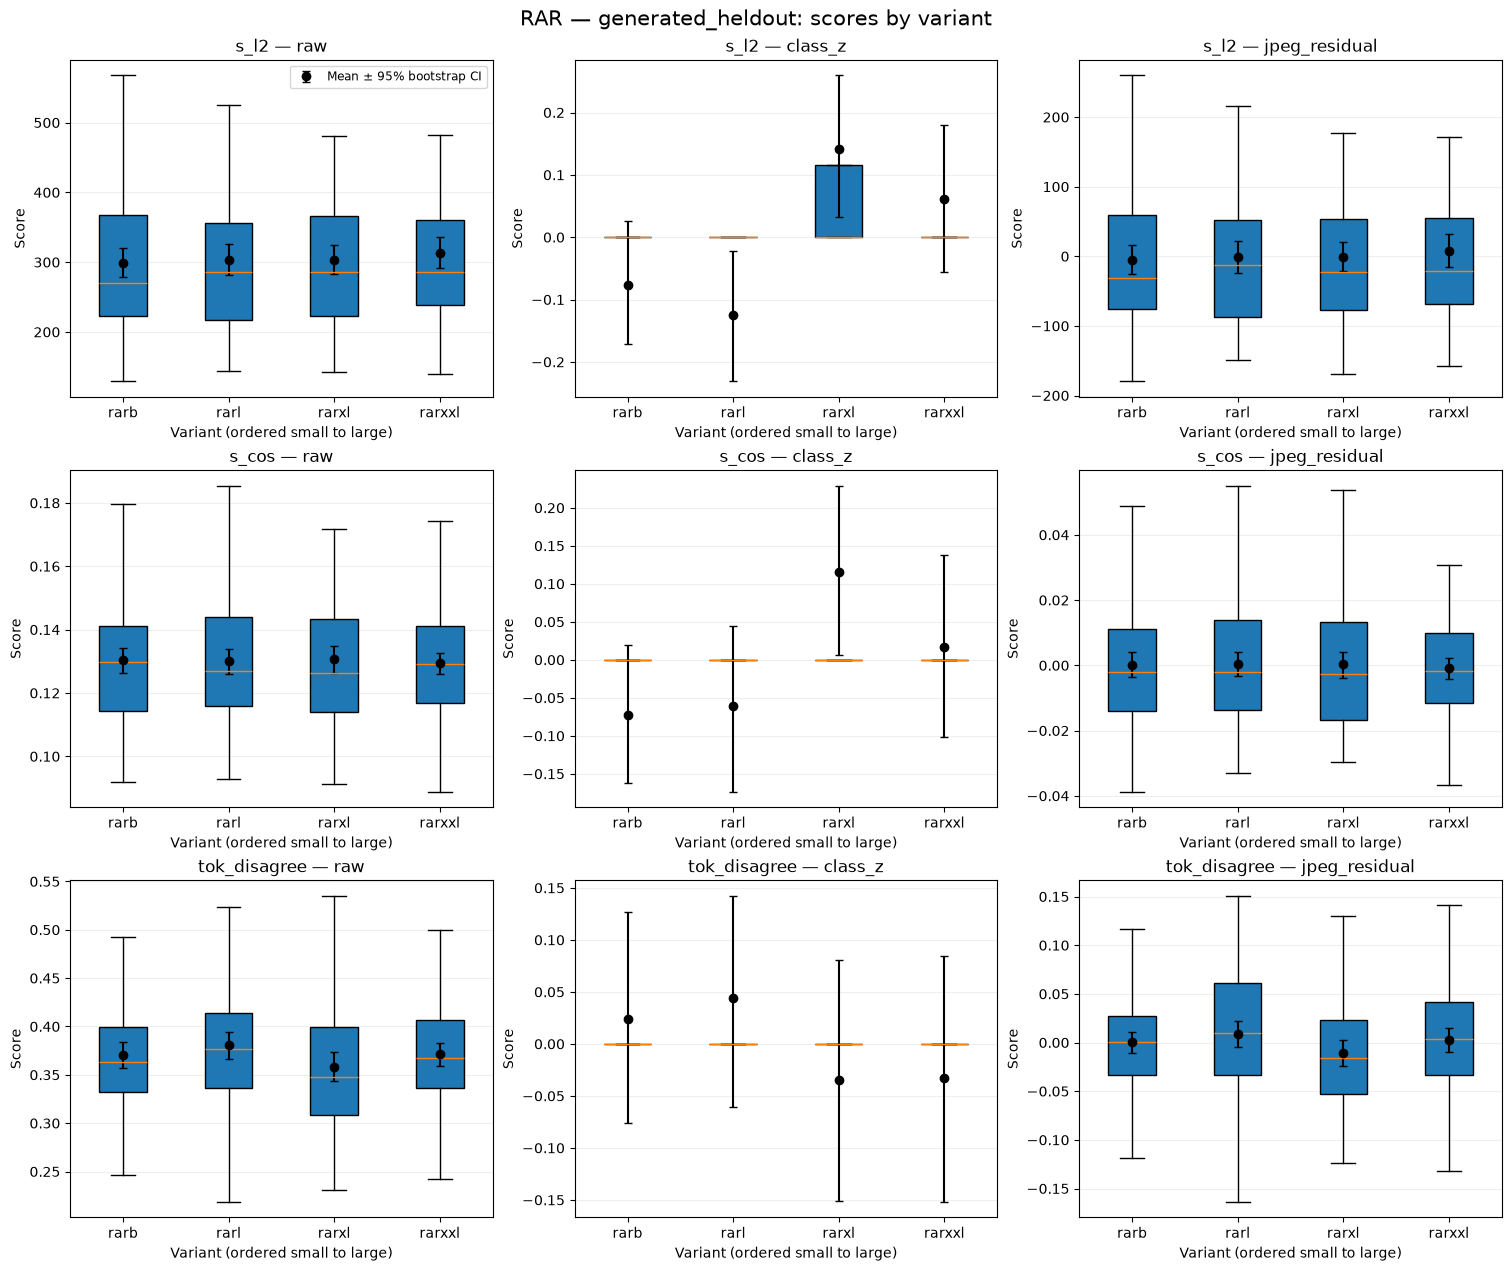

Saved /workspace/results/disagreement/distributions_rar_generated_heldout.png


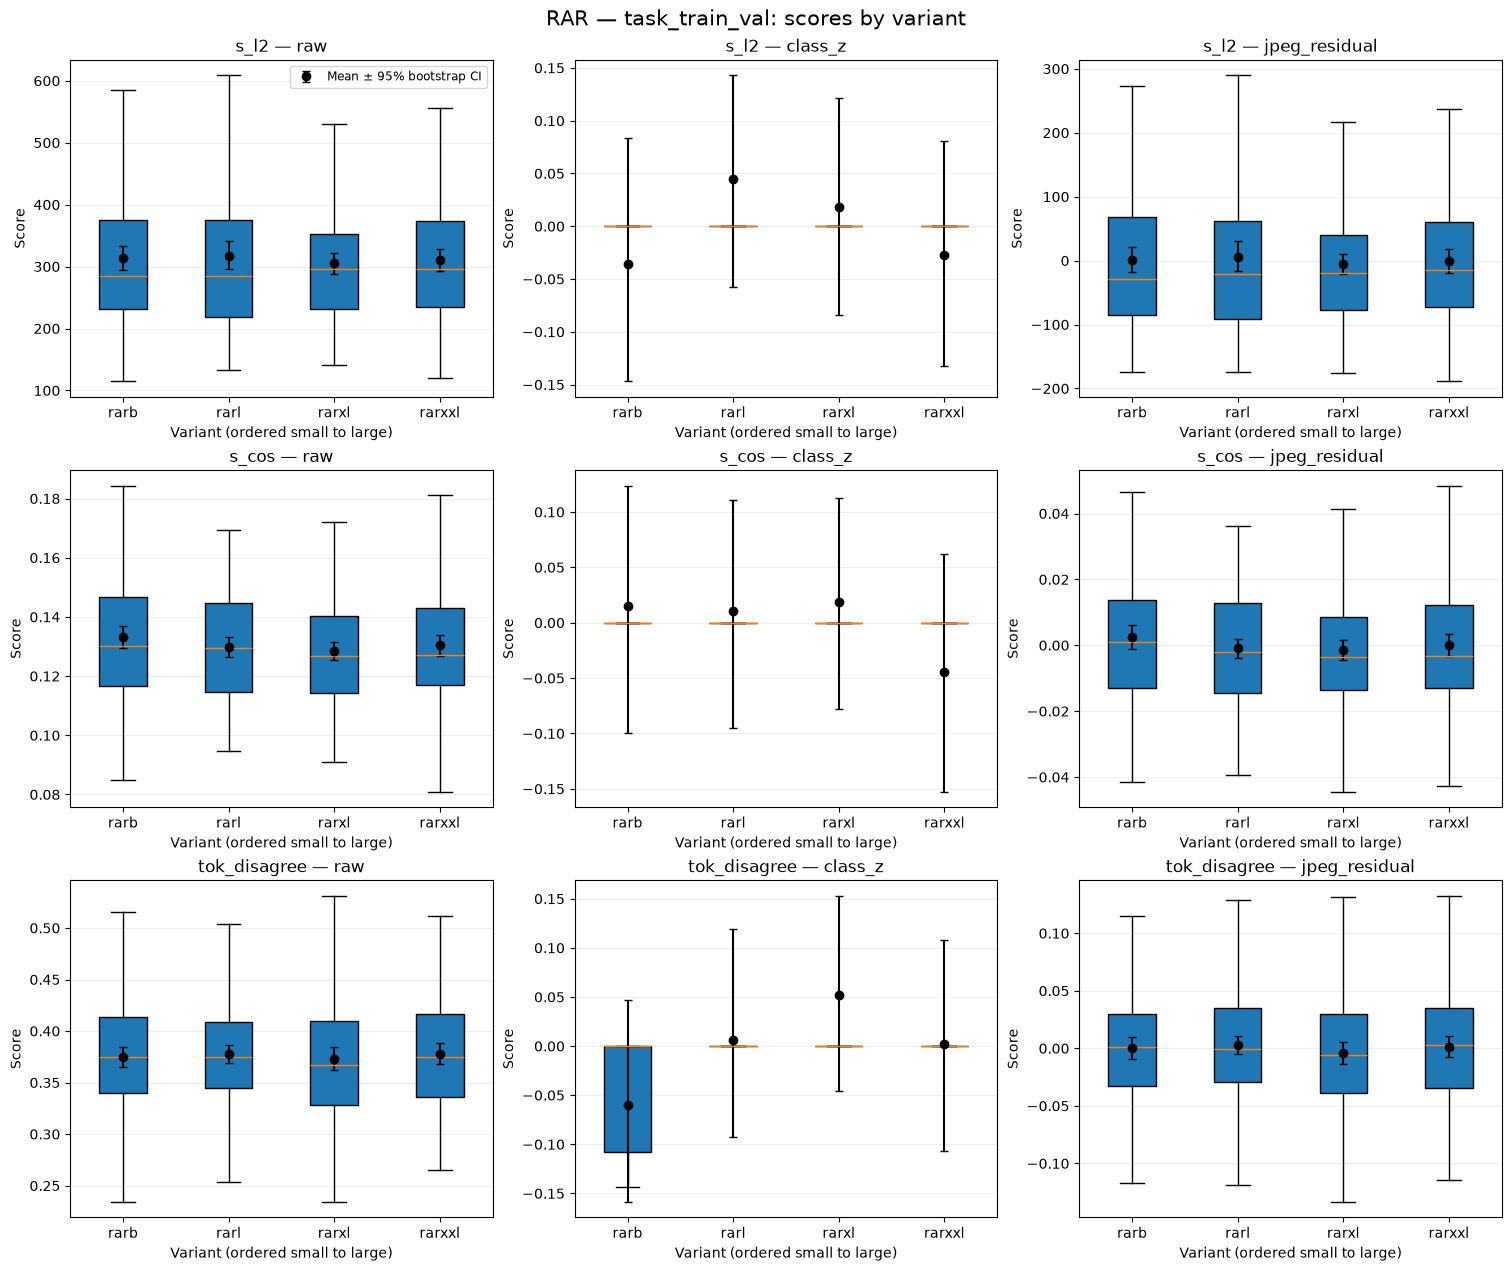

Saved /workspace/results/disagreement/distributions_rar_task_train_val.png


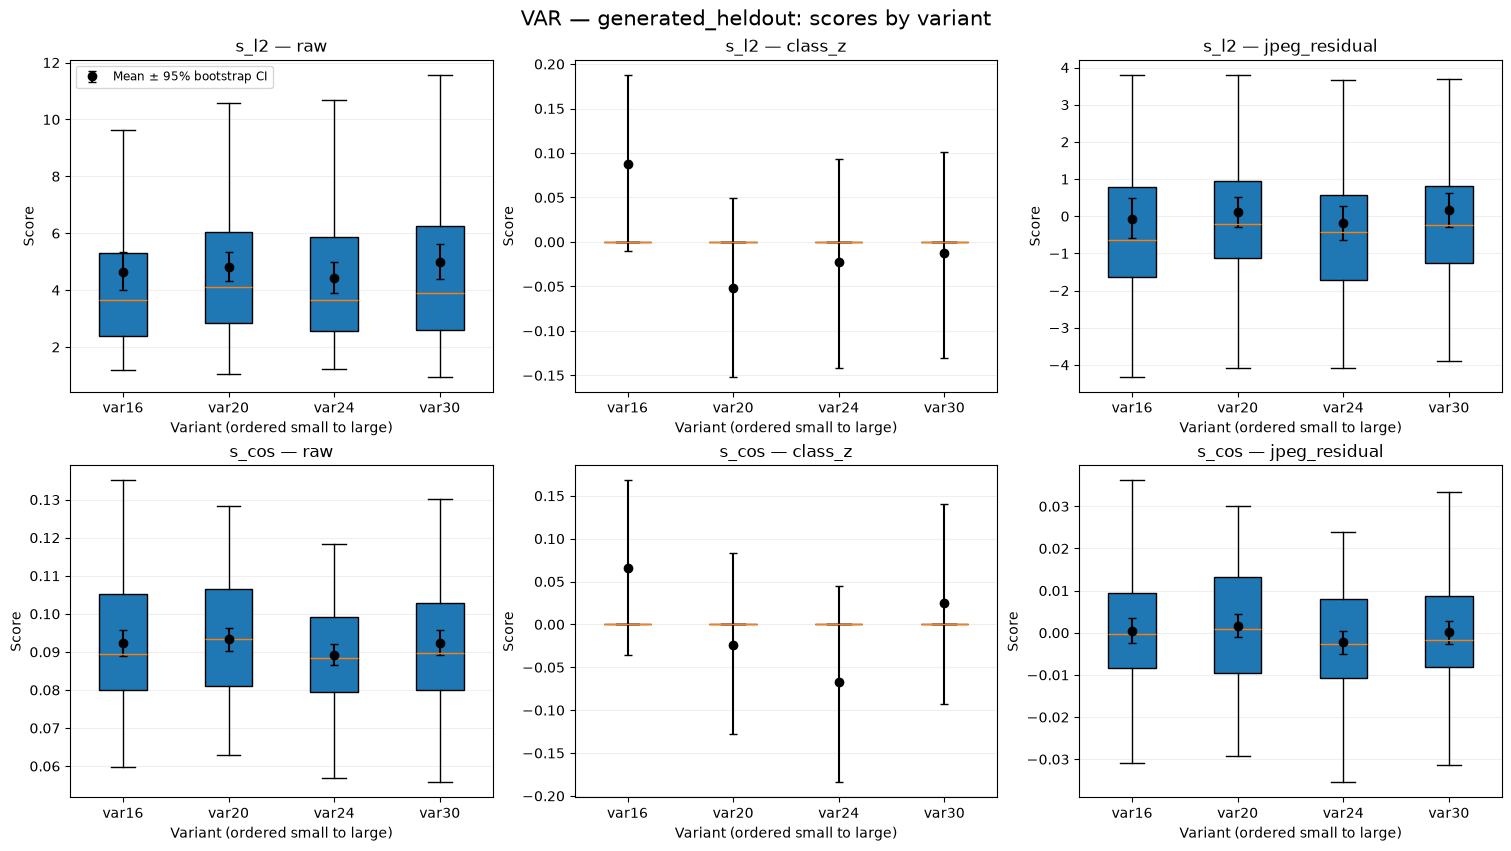

Saved /workspace/results/disagreement/distributions_var_generated_heldout.png


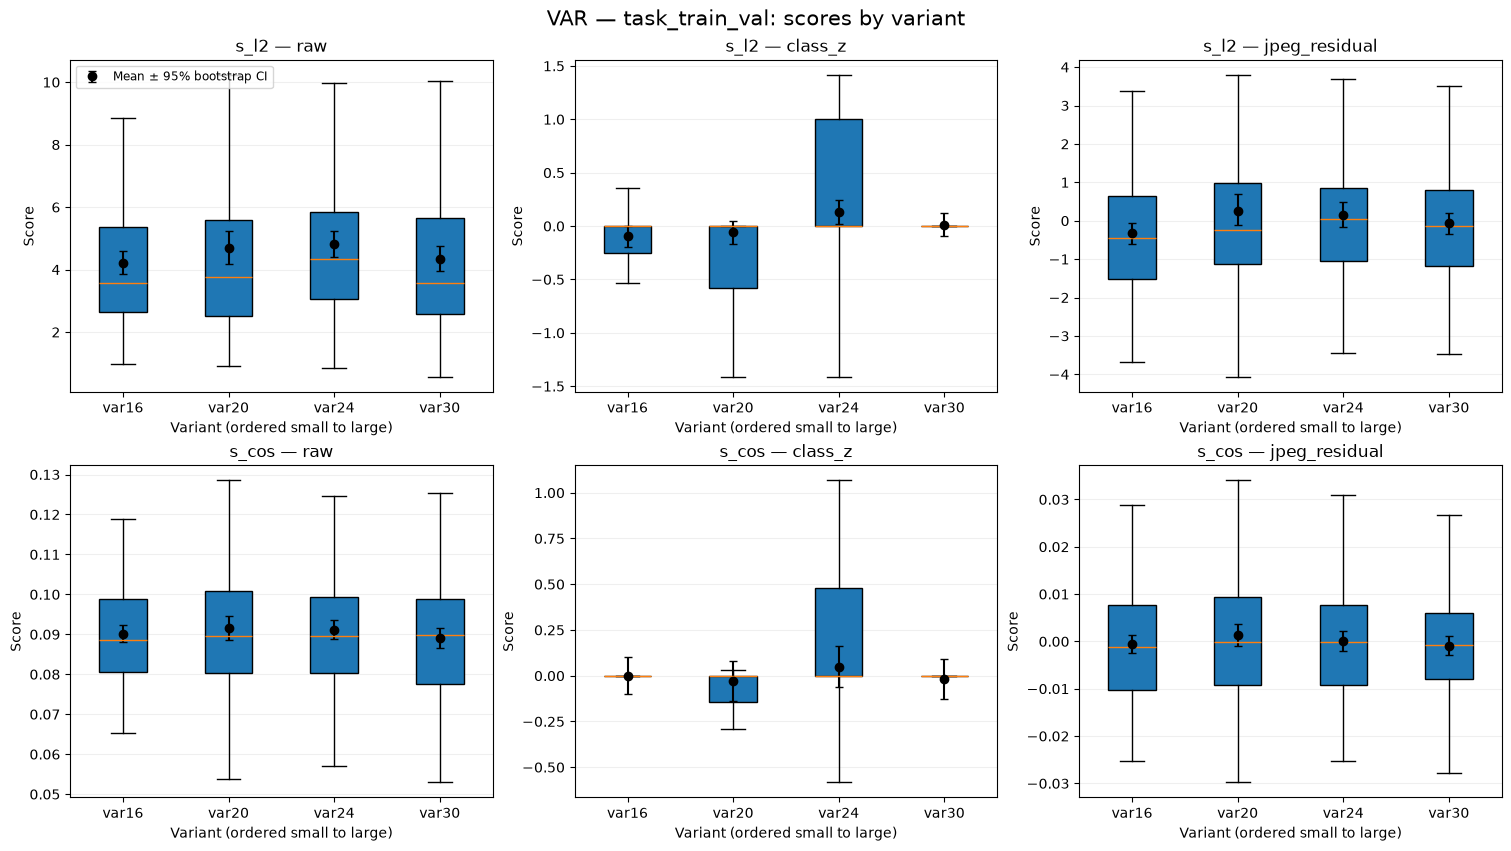

Saved /workspace/results/disagreement/distributions_var_task_train_val.png


,family,cohort,metric,normalization,variant,n,mean,ci95_low,ci95_high
0,rar,generated_heldout,s_l2,raw,rarb,100,299.511683,278.982232,320.608706
1,rar,generated_heldout,s_l2,raw,rarl,100,303.378115,281.126504,326.091803
2,rar,generated_heldout,s_l2,raw,rarxl,100,303.696247,282.992608,324.924495
3,rar,generated_heldout,s_l2,raw,rarxxl,100,312.568120,291.621046,336.712109
4,rar,generated_heldout,s_l2,class_z,rarb,100,-0.077143,-0.170775,0.025732
5,rar,generated_heldout,s_l2,class_z,rarl,100,-0.125410,-0.231036,-0.021841
6,rar,generated_heldout,s_l2,class_z,rarxl,100,0.141622,0.032081,0.259693
7,rar,generated_heldout,s_l2,class_z,rarxxl,100,0.060931,-0.055703,0.180024
8,rar,generated_heldout,s_l2,jpeg_residual,rarb,100,-5.314032,-25.940892,16.575305
9,rar,generated_heldout,s_l2,jpeg_residual,rarl,100,-0.792899,-23.586536,22.109604


In [4]:
def bootstrap_mean_ci(values, rng, replicates=BOOTSTRAP_REPLICATES):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    draws = rng.choice(values, size=(replicates, len(values)), replace=True).mean(axis=1)
    return float(values.mean()), float(np.quantile(draws, 0.025)), float(np.quantile(draws, 0.975))


distribution_rows = []
for family in FAMILIES:
    metrics = score_columns(family)
    for cohort in COHORTS:
        frame = analysis[(family, cohort)]
        fig, axes = plt.subplots(
            len(metrics), len(NORMALIZATIONS),
            figsize=(15, 4.2 * len(metrics)), squeeze=False, constrained_layout=True,
        )
        rng = np.random.default_rng(SEED)
        for row, metric in enumerate(metrics):
            for col, normalization in enumerate(NORMALIZATIONS):
                ax = axes[row, col]
                column = f'{metric}__{normalization}'
                variant_data = [frame.loc[frame.true_label == variant, column].to_numpy() for variant in FAMILIES[family]]
                ax.boxplot(variant_data, tick_labels=FAMILIES[family], showfliers=False, patch_artist=True)
                means, low, high = [], [], []
                for variant, values in zip(FAMILIES[family], variant_data):
                    mean, ci_low, ci_high = bootstrap_mean_ci(values, rng)
                    means.append(mean)
                    low.append(mean - ci_low)
                    high.append(ci_high - mean)
                    distribution_rows.append({
                        'family': family,
                        'cohort': cohort,
                        'metric': metric,
                        'normalization': normalization,
                        'variant': variant,
                        'n': len(values),
                        'mean': mean,
                        'ci95_low': ci_low,
                        'ci95_high': ci_high,
                    })
                x_positions = np.arange(1, len(means) + 1)
                ax.errorbar(x_positions, means, yerr=[low, high], fmt='o', color='black', capsize=3,
                            label='Mean ± 95% bootstrap CI')
                ax.set_title(f'{metric} — {normalization}')
                ax.set_xlabel('Variant (ordered small to large)')
                ax.set_ylabel('Score')
                ax.grid(axis='y', alpha=0.2)
                if row == 0 and col == 0:
                    ax.legend(fontsize='small')
        fig.suptitle(f'{family.upper()} — {cohort}: scores by variant', fontsize=15)
        output = RESULTS / f'distributions_{family}_{cohort}.png'
        fig.savefig(output, dpi=150)
        plt.show()
        print(f'Saved {output}')
distribution_summary = pd.DataFrame(distribution_rows)
display(distribution_summary.head(18))

In [5]:
auc_rows = []
monotonicity_rows = []
for family in FAMILIES:
    variants = FAMILIES[family]
    variant_index = {variant: i for i, variant in enumerate(variants)}
    for cohort in COHORTS:
        frame = analysis[(family, cohort)]
        for metric in score_columns(family):
            for normalization in NORMALIZATIONS:
                column = f'{metric}__{normalization}'
                rho = spearmanr(frame['variant_index'], frame[column]).statistic
                monotonicity_rows.append({
                    'family': family,
                    'cohort': cohort,
                    'metric': metric,
                    'normalization': normalization,
                    'spearman_score_vs_variant_index': rho,
                    'expected_direction': 'negative (larger variants lower score)',
                })
                for low_idx in range(len(variants)):
                    for high_idx in range(low_idx + 1, len(variants)):
                        low_variant, high_variant = variants[low_idx], variants[high_idx]
                        pair = frame[frame.true_label.isin([low_variant, high_variant])]
                        binary_target = (pair.true_label.to_numpy() == high_variant).astype(int)
                        # Lower score predicts the higher-index (larger) variant.
                        auc = roc_auc_score(binary_target, -pair[column].to_numpy())
                        adjacent = high_idx == low_idx + 1
                        extreme = low_idx == 0 and high_idx == len(variants) - 1
                        auc_rows.append({
                            'family': family,
                            'cohort': cohort,
                            'metric': metric,
                            'normalization': normalization,
                            'lower_variant': low_variant,
                            'higher_variant': high_variant,
                            'pair': f'{low_variant} vs {high_variant}',
                            'adjacent': adjacent,
                            'extreme': extreme,
                            'n_each': int((pair.true_label == low_variant).sum()),
                            'auc_larger_variant': auc,
                        })
auc_table = pd.DataFrame(auc_rows)
monotonicity_table = pd.DataFrame(monotonicity_rows)
display(monotonicity_table)

# Every variant-pair AUC; adjacent and extreme comparisons are marked for quick inspection.
display(auc_table.sort_values(['family', 'cohort', 'metric', 'normalization', 'lower_variant', 'higher_variant']))

,family,cohort,metric,normalization,spearman_score_vs_variant_index,expected_direction
0,rar,generated_heldout,s_l2,raw,0.045120,negative (larger variants lower score)
1,rar,generated_heldout,s_l2,class_z,0.138912,negative (larger variants lower score)
2,rar,generated_heldout,s_l2,jpeg_residual,0.041964,negative (larger variants lower score)
3,rar,generated_heldout,s_cos,raw,0.011329,negative (larger variants lower score)
4,rar,generated_heldout,s_cos,class_z,0.083636,negative (larger variants lower score)
5,rar,generated_heldout,s_cos,jpeg_residual,-0.005054,negative (larger variants lower score)
6,rar,generated_heldout,tok_disagree,raw,-0.035340,negative (larger variants lower score)
7,rar,generated_heldout,tok_disagree,class_z,-0.053858,negative (larger variants lower score)
8,rar,generated_heldout,tok_disagree,jpeg_residual,-0.031700,negative (larger variants lower score)
9,rar,task_train_val,s_l2,raw,0.007488,negative (larger variants lower score)


,family,cohort,metric,normalization,lower_variant,higher_variant,pair,adjacent,extreme,n_each,auc_larger_variant
24,rar,generated_heldout,s_cos,class_z,rarb,rarl,rarb vs rarl,True,False,100,0.489550
25,rar,generated_heldout,s_cos,class_z,rarb,rarxl,rarb vs rarxl,False,False,100,0.410700
26,rar,generated_heldout,s_cos,class_z,rarb,rarxxl,rarb vs rarxxl,False,True,100,0.465850
27,rar,generated_heldout,s_cos,class_z,rarl,rarxl,rarl vs rarxl,True,False,100,0.425800
28,rar,generated_heldout,s_cos,class_z,rarl,rarxxl,rarl vs rarxxl,False,False,100,0.478300
...,...,...,...,...,...,...,...,...,...,...,...
145,var,task_train_val,s_l2,raw,var16,var24,var16 vs var24,False,False,150,0.432622
146,var,task_train_val,s_l2,raw,var16,var30,var16 vs var30,False,True,150,0.500356
147,var,task_train_val,s_l2,raw,var20,var24,var20 vs var24,True,False,150,0.444311
148,var,task_train_val,s_l2,raw,var20,var30,var20 vs var30,False,False,150,0.505956


In [6]:
primary = auc_table[auc_table.metric == 's_l2']
threshold_rows = []
for (family, cohort, normalization), group in primary.groupby(['family', 'cohort', 'normalization'], sort=False):
    adjacent = group[group.adjacent]
    extreme = group[group.extreme]
    min_adjacent_auc = float(adjacent.auc_larger_variant.min())
    extreme_auc = float(extreme.auc_larger_variant.iloc[0])
    is_normalized = normalization != 'raw'
    threshold_rows.append({
        'family': family,
        'cohort': cohort,
        'normalization': normalization,
        'worst_adjacent_AUC': min_adjacent_auc,
        'adjacent_cutoff': THRESHOLD_ADJACENT,
        'adjacent_pass': min_adjacent_auc >= THRESHOLD_ADJACENT,
        'extreme_AUC': extreme_auc,
        'extreme_cutoff': THRESHOLD_EXTREME,
        'extreme_pass': extreme_auc >= THRESHOLD_EXTREME,
        'registered_normalization_result': (
            'PASS' if min_adjacent_auc >= THRESHOLD_ADJACENT and extreme_auc >= THRESHOLD_EXTREME else 'FAIL'
        ) if is_normalized else 'reference only',
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)
print('Threshold interpretation: every adjacent pair must meet AUC ≥ 0.60; the extreme pair must meet AUC ≥ 0.70.')
print('Normalized results are evaluated separately for class-z and JPEG-residual scores; raw is a reference.')

# Keep computed tables available as notebook artifacts for downstream review.
distribution_summary.to_csv(RESULTS / 'distribution_summary.csv', index=False)
monotonicity_table.to_csv(RESULTS / 'monotonicity.csv', index=False)
auc_table.to_csv(RESULTS / 'pairwise_auc.csv', index=False)
threshold_table.to_csv(RESULTS / 'threshold_summary.csv', index=False)
print(f'Saved summaries and plots to {RESULTS}')

,family,cohort,normalization,worst_adjacent_AUC,adjacent_cutoff,adjacent_pass,extreme_AUC,extreme_cutoff,extreme_pass,registered_normalization_result
0,rar,generated_heldout,raw,0.480300,0.6,False,0.461400,0.7,False,reference only
1,rar,generated_heldout,class_z,0.391450,0.6,False,0.439000,0.7,False,FAIL
2,rar,generated_heldout,jpeg_residual,0.480000,0.6,False,0.465700,0.7,False,FAIL
3,rar,task_train_val,raw,0.486311,0.6,False,0.494533,0.7,False,reference only
4,rar,task_train_val,class_z,0.464133,0.6,False,0.491333,0.7,False,FAIL
5,rar,task_train_val,jpeg_residual,0.486489,0.6,False,0.493511,0.7,False,FAIL
6,var,generated_heldout,raw,0.442900,0.6,False,0.457000,0.7,False,reference only
7,var,generated_heldout,class_z,0.489300,0.6,False,0.542050,0.7,False,FAIL
8,var,generated_heldout,jpeg_residual,0.431200,0.6,False,0.443000,0.7,False,FAIL
9,var,task_train_val,raw,0.444311,0.6,False,0.500356,0.7,False,reference only


Threshold interpretation: every adjacent pair must meet AUC ≥ 0.60; the extreme pair must meet AUC ≥ 0.70.
Normalized results are evaluated separately for class-z and JPEG-residual scores; raw is a reference.
Saved summaries and plots to /workspace/results/disagreement
